# Data Mining Assignment
*CDS6314 - Group 08*


Team Members:


1.   Ng Wei Da (1211107034)
2.   Chan Zheng Uee (1231302741)
3.   Teo Hock Seng (1231302732)
4.   Belinda Kiong Szeling (1211112100)



# 0. Introduction

This notebook performs association rule mining on marital satisfaction data from 33 countries. The dataset contains various attributes about individual including demographic information, marital status, religious affiliation, and measures of marital satisfaction.

Our goal is to discover interesting associations between these attributes that might reveal patterns in marital satisfaction across different populations.



Exploratory Questions:

1. Does the combination of high self-esteem, happiness, and love predict higher marital satisfaction in men?

2. Is having no children a significant moderator for emotional factors in high marital satisfaction in women?

3. Does low self-esteem strongly predict low marital satisfaction.

4. Do individuals with high self-esteem but low love still experience low marital satisfaction?

## 1. Data Initialization

### Import libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
import random
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

### Define functions

Functions for data preprocessing:

In [ ]:
def describe_variable(df, var, new_scheme=False):
    print(var, ":")
    print(
        "Unique variable description: ",
        variable_table[variable_table["new_variable_name"] == var][
            "description"
        ].unique()[0],
    )

    # Get unique values after dropping NA
    unique_vals = df[var].unique()

    # Check if the column is numeric
    if df[var].dtype in ["int64", "float64", "int32", "float32"]:
        unique_values = [float(x) for x in unique_vals]
        print("Unique values in data: ", sorted(unique_values))
    else:
        # For non-numeric (e.g., strings), keep as is and sort
        unique_values = sorted([str(x) for x in unique_vals])
        print("Unique values in data: ", unique_values)

    if new_scheme:
        print(
            "Unique variable new scheme: ",
            variable_table[variable_table["new_variable_name"] == var][
                "new_scheme"
            ].unique()[0],
        )
    else:
        print(
            "Unique variable scheme: ",
            variable_table[variable_table["new_variable_name"] == var][
                "scheme"
            ].unique()[0],
        )
    print()

In [ ]:
def reverse_range(df, col):
    max = df[col].max()
    min = df[col].min()
    return (max + min) - df[col]

In [ ]:
def rescale_range(df, col):
    df[col] = 1 + (marital_df_cleaned[col] - 1) * (4 / 6)
    return df[col].round()

Functions for data visualization:

In [ ]:
def plot_categorical(df, cols):
    for col in cols:
        plt.figure(figsize=(12, 4))
        sns.countplot(data=df, x=col)
        plt.title(f"Distribution of {col}")
        plt.xticks(rotation=45, ha="right")
        plt.show()
        print()


def plot_numerical(df, cols):
    for col in cols:
        plt.figure(figsize=(10, 6))

        plt.subplot(2, 1, 1)
        sns.histplot(data=df, x=col, kde=True)
        plt.title(f"Distribution of {col}")

        plt.subplot(2, 1, 2)
        sns.boxplot(data=df, x=col, orient="h")

        plt.tight_layout()
        plt.show()
        print()

In [ ]:
def plot_stacked_barchart(df, column, index_list, subplot=True):
    num_plots = len(index_list)

    if subplot:
        # General calculation: find the most square-like grid possible
        cols = math.ceil(math.sqrt(num_plots))
        rows = math.ceil(num_plots / cols)

        fig, axes = plt.subplots(
            rows, cols, figsize=(5 * cols, 4 * rows), squeeze=False
        )

        for idx, index in enumerate(index_list):
            row_idx, col_idx = divmod(idx, cols)
            ax = axes[row_idx][col_idx]

            # Prepare data
            pivot_df = pd.pivot_table(
                data=df,
                index=index,
                columns=column,
                aggfunc="size",
                observed=False,
            )
            pivot_percent = pivot_df.div(pivot_df.sum(axis=1), axis=0) * 100

            # Plot
            pivot_percent.plot(kind="barh", stacked=True, ax=ax, legend=False)
            ax.set_title(f"{index} by {column}")
            ax.set_xlabel("Percentage, %")
            ax.set_ylabel(index)
            ax.tick_params(axis="x", rotation=45)

        # Remove any unused axes
        for idx in range(num_plots, rows * cols):
            row_idx, col_idx = divmod(idx, cols)
            fig.delaxes(axes[row_idx][col_idx])

        # Shared legend
        handles, labels = axes[0][0].get_legend_handles_labels()
        fig.legend(
            handles,
            labels,
            title=column,
            bbox_to_anchor=(1.05, 0.5),
            loc="center left",
        )

        plt.tight_layout()
        plt.show()

    else:
        for index in index_list:
            pivot_df = pd.pivot_table(
                data=df, index=index, columns=column, aggfunc="size"
            )
            pivot_percent = pivot_df.div(pivot_df.sum(axis=1), axis=0) * 100

            pivot_percent.plot(kind="barh", stacked=True, figsize=(10, 6))
            plt.title(f"Distribution of {index} by {column}")
            plt.xlabel("Percentage, %")
            plt.ylabel(index)
            plt.xticks(rotation=45)
            plt.tight_layout()
            plt.show()

In [ ]:
def plot_single_numerical(df, column, group_col=None):
    # Define consistent color palette if group_col is used
    palette = None
    if group_col:
        unique_groups = df[group_col].dropna().unique()
        palette = sns.color_palette("Set1", len(unique_groups))

    # Create figure with two subplots
    plt.figure(figsize=(10, 6))

    # Stacked Histogram
    plt.subplot(2, 1, 1)
    if group_col:
        # Use multiple="stack" for stacked histograms
        ax1 = sns.histplot(
            data=df,
            x=column,
            hue=group_col,
            kde=True,
            multiple="stack",
            palette=palette,
        )
    else:
        # Single histogram for ungrouped data
        ax1 = sns.histplot(data=df, x=column, kde=True, color="skyblue")
    ax1.set_title(
        f"Distribution of {column}" + (f" by {group_col}" if group_col else "")
    )
    ax1.set_xlabel("")  # Hide x-axis label
    ax1.set_xticks([])  # Hide x-axis ticks

    # Boxplot
    plt.subplot(2, 1, 2)
    if group_col:
        sns.boxplot(
            data=df,
            x=column,
            y=group_col,
            hue=group_col,
            orient="h",
            palette=palette,
            legend=False,
        )
    else:
        sns.boxplot(
            data=df, x=column, orient="h", color="skyblue"
        )  # Single color for ungrouped

    plt.tight_layout()
    plt.show()


def plot_multiple_numerical(df, column_list, group_col=None):
    for column in column_list:
        plot_single_numerical(df, column, group_col)
        print()

### Data Initialization

In [ ]:
marital_df  = pd.read_excel("Marital satisfaction_Data.xlsx")
variable_table = pd.read_excel("variable_table.xlsx")

Data preview:

In [ ]:
marital_df.head()

,Country,"Sex (1-M, 2-F)",Age,Marriage duration (years),Number of children,Number of brought up children,"Education (1-no formal education, 2-primary school, 3-secondary school, 4-high school or technical college, 5-bachelor or master degree)","Material status (1-much better than average in my country, 2-better than average in my country, 3-similar to average in my country, 4-worse than average in my country, 5-much worse than average in my country)","Religion (1-Protestant, 2-Catholic, 3-Jewish, 4-Muslim, 5-Buddhist, 6-None, 7-Jehovah, 8-Evangelic, 9-Spiritualism, 10-Other - very specific, 11-Orthodox, 12-Hinduism)","Religiosity (1-not religious at all, 7-extremely religious)",...,Unnamed: 21,Unnamed: 22,"Collectivism-Individualism (GLOBE survey) (1-strongly agree, 4-neither agree nor disagree, 7-strongly disagree)",Unnamed: 24,Unnamed: 25,Unnamed: 26,Unnamed: 27,Unnamed: 28,Unnamed: 29,Unnamed: 30
0,Item number,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,...,21.0,22.0,1,2.0,3.0,4.0,1,2.0,3.0,4.0
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,National level,NaN,NaN,NaN,Individual level,NaN,NaN,NaN
2,Brazil,1.0,21.0,2.0,0.0,0.0,5.0,3.0,1.0,4.0,...,7.0,7.0,1,1.0,1.0,1.0,1,1.0,1.0,1.0
3,Brazil,1.0,29.0,3.0,1.0,0.0,5.0,3.0,1.0,6.0,...,6.0,6.0,2,1.0,1.0,1.0,1,1.0,1.0,1.0
4,Brazil,1.0,30.0,7.0,0.0,0.0,5.0,3.0,1.0,4.0,...,7.0,7.0,2,1.0,2.0,1.0,1,1.0,1.0,1.0


## 2. Data Preprocessing Part 1: Basic Data Cleaning

Replace column names from raw data with new variable names.

In [ ]:
new_columns = variable_table['new_variable_name'].values
new_columns

array(['country', 'sex', 'age', 'marriage_duration', 'num_children',
       'num_brought_up_children', 'education', 'physical', 'religion',
       'religiosity', 'safety', 'love1', 'happy', 'love2', 'love3',
       'love4', 'esteem1', 'esteem2', 'love5', 'love6', 'ms1', 'ms2',
       'ms3', 'esteem3', 'esteem4', 'love7', 'love8', 'esteem5',
       'esteem6', 'love9', 'love10'], dtype=object)

Create copy of raw data for data cleaning.

In [ ]:
marital_df_cleaned = marital_df.copy()

### Variable Mapping

In [ ]:
# Drop the first two row
marital_df_cleaned = marital_df_cleaned.iloc[2:]

# Replace new column names
marital_df_cleaned.columns = new_columns

# Reset index
marital_df_cleaned = marital_df_cleaned.reset_index(drop=True)

marital_df_cleaned.head()

,country,sex,age,marriage_duration,num_children,num_brought_up_children,education,physical,religion,religiosity,...,ms2,ms3,esteem3,esteem4,love7,love8,esteem5,esteem6,love9,love10
0,Brazil,1.0,21.0,2.0,0.0,0.0,5.0,3.0,1.0,4.0,...,7.0,7.0,1,1.0,1.0,1.0,1,1.0,1.0,1.0
1,Brazil,1.0,29.0,3.0,1.0,0.0,5.0,3.0,1.0,6.0,...,6.0,6.0,2,1.0,1.0,1.0,1,1.0,1.0,1.0
2,Brazil,1.0,30.0,7.0,0.0,0.0,5.0,3.0,1.0,4.0,...,7.0,7.0,2,1.0,2.0,1.0,1,1.0,1.0,1.0
3,Brazil,1.0,30.0,7.0,1.0,1.0,5.0,3.0,1.0,6.0,...,6.0,6.0,3,1.0,1.0,2.0,1,1.0,1.0,1.0
4,Brazil,1.0,28.0,9.0,0.0,0.0,4.0,2.0,1.0,5.0,...,6.0,7.0,3,2.0,3.0,2.0,1,1.0,1.0,1.0


### Data Deletion

Based on the 4 exploratory questions above, the columns required are: sex, num_children, education, love1, love2, love3, love4, love5, love6, love7, love8, love9,	love10, ms1, ms2, ms3, esteem1, esteem2, esteem3, esteem4	esteem5, esteem6, happy

Rows to drop: country, age, marraige_duration, num_brought_up_children, physical, religion, religiosity, safety

In [ ]:
to_drop_columns = [
    "country",
    "age",
    "marriage_duration",
    "num_brought_up_children",
    "physical",
    "religion",
    "religiosity",
    "safety",
]

In [ ]:
marital_df_cleaned.drop(columns=to_drop_columns, inplace=True)
marital_df_cleaned.head()

,sex,num_children,education,love1,happy,love2,love3,love4,esteem1,esteem2,...,ms2,ms3,esteem3,esteem4,love7,love8,esteem5,esteem6,love9,love10
0,1.0,0.0,5.0,1.0,1.0,1.0,1.0,2.0,2.0,1.0,...,7.0,7.0,1,1.0,1.0,1.0,1,1.0,1.0,1.0
1,1.0,1.0,5.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,6.0,6.0,2,1.0,1.0,1.0,1,1.0,1.0,1.0
2,1.0,0.0,5.0,1.0,1.0,2.0,1.0,1.0,1.0,1.0,...,7.0,7.0,2,1.0,2.0,1.0,1,1.0,1.0,1.0
3,1.0,1.0,5.0,1.0,1.0,1.0,1.0,1.0,1.0,2.0,...,6.0,6.0,3,1.0,1.0,2.0,1,1.0,1.0,1.0
4,1.0,0.0,4.0,1.0,2.0,1.0,1.0,1.0,1.0,1.0,...,6.0,7.0,3,2.0,3.0,2.0,1,1.0,1.0,1.0


### Remove Duplicates

Check duplicated rows.

In [ ]:
# Binary mapping to check for duplicates
duplicates_bm = marital_df_cleaned.duplicated(keep=False)
marital_df_cleaned[duplicates_bm]

,sex,num_children,education,love1,happy,love2,love3,love4,esteem1,esteem2,...,ms2,ms3,esteem3,esteem4,love7,love8,esteem5,esteem6,love9,love10
9,2.0,1.0,5.0,3.0,5.0,2.0,2.0,2.0,1.0,2.0,...,1.0,1.0,3,1.0,4.0,1.0,1,1.0,4.0,2.0
18,1.0,0.0,5.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,7.0,7.0,1,1.0,2.0,2.0,1,1.0,2.0,1.0
49,2.0,1.0,5.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,7.0,7.0,4,3.0,4.0,2.0,2,1.0,4.0,3.0
50,2.0,1.0,5.0,1.0,3.0,1.0,1.0,1.0,1.0,1.0,...,5.0,5.0,3,1.0,3.0,5.0,3,2.0,4.0,5.0
109,1.0,1.0,5.0,2.0,3.0,2.0,2.0,3.0,3.0,3.0,...,3.0,2.0,1,1.0,3.0,2.0,1,1.0,3.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6793,2.0,3.0,2.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,7.0,7.0,1,1.0,1.0,1.0,1,1.0,1.0,1.0
6794,1.0,2.0,5.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,7.0,7.0,1,1.0,1.0,1.0,1,1.0,1.0,1.0
6859,2.0,1.0,4.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,7.0,7.0,1,1.0,3.0,2.0,1,1.0,3.0,2.0
6888,1.0,2.0,5.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,7.0,7.0,1,1.0,1.0,1.0,1,1.0,3.0,3.0


This shows that there are duplicate rows in the dataset, and almost all of these duplicates comes right after the original occurences, assuming that the respondence might have keyed in the same survey multiple times. Thus, it is safe to remove the duplicated rows, since they are not meaningful.

In [ ]:
# Drop duplicates and reset index
marital_df_cleaned = marital_df_cleaned.drop_duplicates()
marital_df_cleaned = marital_df_cleaned.reset_index(drop=True)

# Check any duplicates
print(marital_df_cleaned.duplicated().sum())

0


### Data Values Checking

In [ ]:
marital_df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6987 entries, 0 to 6986
Data columns (total 23 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sex           6987 non-null   float64
 1   num_children  6987 non-null   float64
 2   education     6987 non-null   float64
 3   love1         6987 non-null   float64
 4   happy         6987 non-null   float64
 5   love2         6987 non-null   float64
 6   love3         6987 non-null   float64
 7   love4         6987 non-null   float64
 8   esteem1       6987 non-null   float64
 9   esteem2       6987 non-null   float64
 10  love5         6987 non-null   float64
 11  love6         6987 non-null   float64
 12  ms1           6987 non-null   float64
 13  ms2           6987 non-null   float64
 14  ms3           6987 non-null   float64
 15  esteem3       6987 non-null   object 
 16  esteem4       6987 non-null   float64
 17  love7         6987 non-null   float64
 18  love8         6987 non-null 

Describe the data with each variable's unique values.

In [ ]:
for col in marital_df_cleaned.columns:
    describe_variable(marital_df_cleaned, col)

sex :
Unique variable description:  Sex
Unique values in data:  [1.0, 2.0]
Unique variable scheme:  1-M, 2-F

num_children :
Unique variable description:  How many children do you have?
Unique values in data:  [0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 11.0, 12.0]
Unique variable scheme:  Total number of children

education :
Unique variable description:  Education
Unique values in data:  [1.0, 2.0, 3.0, 4.0, 5.0]
Unique variable scheme:  1-no formal education, 2-primary school, 3-secondary school, 4-high school or technical college, 5-bachelor or master degree

love1 :
Unique variable description:  Do you enjoy your husband’s/wife’s company?
Unique values in data:  [1.0, 2.0, 3.0, 4.0, 5.0, 6.0]
Unique variable scheme:  1-yes, 3-neither yes nor no, 5-no

happy :
Unique variable description:  Are you happy?
Unique values in data:  [1.0, 2.0, 3.0, 4.0, 5.0]
Unique variable scheme:  1-yes, 3-neither yes nor no, 5-no

love2 :
Unique variable description:  Do you find your hu

There are some issues to fix:

1) esteem3 and esteem5 are object type, but they are numeric. Seems like no issue for the values of those attributes, let's turn them to numeric.

2) Some attributes have a range exceeding the boundary, that are: physical, love1, esteem2, love5, love6

Issue 1 fix:

In [ ]:
marital_df_cleaned['esteem3'] = pd.to_numeric(marital_df_cleaned['esteem3'])
marital_df_cleaned['esteem5'] = pd.to_numeric(marital_df_cleaned['esteem5'])

marital_df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6987 entries, 0 to 6986
Data columns (total 23 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sex           6987 non-null   float64
 1   num_children  6987 non-null   float64
 2   education     6987 non-null   float64
 3   love1         6987 non-null   float64
 4   happy         6987 non-null   float64
 5   love2         6987 non-null   float64
 6   love3         6987 non-null   float64
 7   love4         6987 non-null   float64
 8   esteem1       6987 non-null   float64
 9   esteem2       6987 non-null   float64
 10  love5         6987 non-null   float64
 11  love6         6987 non-null   float64
 12  ms1           6987 non-null   float64
 13  ms2           6987 non-null   float64
 14  ms3           6987 non-null   float64
 15  esteem3       6987 non-null   int64  
 16  esteem4       6987 non-null   float64
 17  love7         6987 non-null   float64
 18  love8         6987 non-null 

Issue 2 fix:

In [ ]:
exceeded_range_attr = ["love1", "esteem2", "love5", "love6"]

for col in exceeded_range_attr:
    describe_variable(marital_df_cleaned, col)

love1 :
Unique variable description:  Do you enjoy your husband’s/wife’s company?
Unique values in data:  [1.0, 2.0, 3.0, 4.0, 5.0, 6.0]
Unique variable scheme:  1-yes, 3-neither yes nor no, 5-no

esteem2 :
Unique variable description:  Are you proud of your husband/wife?
Unique values in data:  [1.0, 2.0, 3.0, 4.0, 5.0, 7.0]
Unique variable scheme:  1-yes, 3-neither yes nor no, 5-no

love5 :
Unique variable description:  Does your relationship have a romantic side?
Unique values in data:  [1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0]
Unique variable scheme:  1-yes, 3-neither yes nor no, 5-no

love6 :
Unique variable description:  Do you love your husband/wife?
Unique values in data:  [1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0]
Unique variable scheme:  1-yes, 3-neither yes nor no, 5-no



These values are treated as outliers that most likely caused by error, so replace those value that exceeds the boundary with the max of scale.

In [ ]:
for col in exceeded_range_attr:
    marital_df_cleaned[col] = marital_df_cleaned[col].apply(
        lambda x: 5 if x > 5 else x
    )
    describe_variable(marital_df_cleaned, col)

love1 :
Unique variable description:  Do you enjoy your husband’s/wife’s company?
Unique values in data:  [1.0, 2.0, 3.0, 4.0, 5.0]
Unique variable scheme:  1-yes, 3-neither yes nor no, 5-no

esteem2 :
Unique variable description:  Are you proud of your husband/wife?
Unique values in data:  [1.0, 2.0, 3.0, 4.0, 5.0]
Unique variable scheme:  1-yes, 3-neither yes nor no, 5-no

love5 :
Unique variable description:  Does your relationship have a romantic side?
Unique values in data:  [1.0, 2.0, 3.0, 4.0, 5.0]
Unique variable scheme:  1-yes, 3-neither yes nor no, 5-no

love6 :
Unique variable description:  Do you love your husband/wife?
Unique values in data:  [1.0, 2.0, 3.0, 4.0, 5.0]
Unique variable scheme:  1-yes, 3-neither yes nor no, 5-no



### Range Reversal

Some data direction are of 1 for bad and 5 (or 7) for good, but some are the opposite. We identify those attributes with opposite range direction and reverse them.

In [ ]:
ordinal_bm = variable_table["type"] == "Ordinal"
ordinal_attr = variable_table[ordinal_bm]["new_variable_name"].values
ordinal_attr = [col for col in marital_df_cleaned.columns]

for col in ordinal_attr:
    describe_variable(marital_df_cleaned, col)

sex :
Unique variable description:  Sex
Unique values in data:  [1.0, 2.0]
Unique variable scheme:  1-M, 2-F

num_children :
Unique variable description:  How many children do you have?
Unique values in data:  [0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 11.0, 12.0]
Unique variable scheme:  Total number of children

education :
Unique variable description:  Education
Unique values in data:  [1.0, 2.0, 3.0, 4.0, 5.0]
Unique variable scheme:  1-no formal education, 2-primary school, 3-secondary school, 4-high school or technical college, 5-bachelor or master degree

love1 :
Unique variable description:  Do you enjoy your husband’s/wife’s company?
Unique values in data:  [1.0, 2.0, 3.0, 4.0, 5.0]
Unique variable scheme:  1-yes, 3-neither yes nor no, 5-no

happy :
Unique variable description:  Are you happy?
Unique values in data:  [1.0, 2.0, 3.0, 4.0, 5.0]
Unique variable scheme:  1-yes, 3-neither yes nor no, 5-no

love2 :
Unique variable description:  Do you find your husband

reversed attributes are esteem1 to esteem6, happy, love1 to love10, physical, and safety

In [ ]:
reversed_attr = [
    "esteem1",
    "esteem2",
    "esteem3",
    "esteem4",
    "esteem5",
    "esteem6",
    "happy",
    "love1",
    "love2",
    "love3",
    "love4",
    "love5",
    "love6",
    "love7",
    "love8",
    "love9",
    "love10",
]

In [ ]:
for col in reversed_attr:
    marital_df_cleaned[col] = reverse_range(marital_df_cleaned, col)
    describe_variable(marital_df_cleaned, col)

esteem1 :
Unique variable description:  Do you respect your husband/wife?
Unique values in data:  [1.0, 2.0, 3.0, 4.0, 5.0]
Unique variable scheme:  1-yes, 3-neither yes nor no, 5-no

esteem2 :
Unique variable description:  Are you proud of your husband/wife?
Unique values in data:  [1.0, 2.0, 3.0, 4.0, 5.0]
Unique variable scheme:  1-yes, 3-neither yes nor no, 5-no

esteem3 :
Unique variable description:  In this society, children take pride in the individual accomplishments of their parents.
Unique values in data:  [1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0]
Unique variable scheme:  1-strongly agree, 4-neither agree nor disagree, 7-strongly disagree

esteem4 :
Unique variable description:  In this society, parents take pride in the individual accomplishments of their children.
Unique values in data:  [1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0]
Unique variable scheme:  1-strongly agree, 4-neither agree nor disagree, 7-strongly disagree

esteem5 :
Unique variable description:  I think, children should

### Range scalling

Scale all likert scale data to 1-5 only.

In [ ]:
scale_attr = [
    "esteem3",
    "esteem4",
    "esteem5",
    "esteem6",
    "love7",
    "love8",
    "love9",
    "love10",
    "ms1",
    "ms2",
    "ms3",
]

In [ ]:
for col in scale_attr:
    marital_df_cleaned[col] = rescale_range(marital_df_cleaned, col)
    describe_variable(marital_df_cleaned, col, True)

esteem3 :
Unique variable description:  In this society, children take pride in the individual accomplishments of their parents.
Unique values in data:  [1.0, 2.0, 3.0, 4.0, 5.0]
Unique variable new scheme:  1-strongly disagree, 2-disagree, 3-neutral, 4-agree, 5-strongly agree

esteem4 :
Unique variable description:  In this society, parents take pride in the individual accomplishments of their children.
Unique values in data:  [1.0, 2.0, 3.0, 4.0, 5.0]
Unique variable new scheme:  1-strongly disagree, 2-disagree, 3-neutral, 4-agree, 5-strongly agree

esteem5 :
Unique variable description:  I think, children should take pride in the individual accomplishments of their parents.
Unique values in data:  [1.0, 2.0, 3.0, 4.0, 5.0]
Unique variable new scheme:  1-strongly disagree, 2-disagree, 3-neutral, 4-agree, 5-strongly agree

esteem6 :
Unique variable description:  I think, parents should take pride in the individual accomplishments of their children.
Unique values in data:  [1.0, 2.0, 3

### Export cleaned dataset

In [ ]:
marital_df_cleaned.head()

,sex,num_children,education,love1,happy,love2,love3,love4,esteem1,esteem2,...,ms2,ms3,esteem3,esteem4,love7,love8,esteem5,esteem6,love9,love10
0,1.0,0.0,5.0,5.0,5.0,5.0,5.0,4.0,4.0,5.0,...,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0
1,1.0,1.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,...,4.0,4.0,4.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0
2,1.0,0.0,5.0,5.0,5.0,4.0,5.0,5.0,5.0,5.0,...,5.0,5.0,4.0,5.0,4.0,5.0,5.0,5.0,5.0,5.0
3,1.0,1.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,4.0,...,4.0,4.0,4.0,5.0,5.0,4.0,5.0,5.0,5.0,5.0
4,1.0,0.0,4.0,5.0,4.0,5.0,5.0,5.0,5.0,5.0,...,4.0,5.0,4.0,4.0,4.0,4.0,5.0,5.0,5.0,5.0


In [ ]:
marital_df_cleaned.to_csv('marital_data_cleaned.csv', index=False)

## 3. Data Exploration (EDA)

In [ ]:
marital_satisfaction_columns = ["ms1", "ms2", "ms3"]
love_columns = [("love" + str(i)) for i in range(1, 11)]
esteem_columns = [("esteem" + str(i)) for i in range(1, 7)]
ordinal_columns = ["education"] + love_columns + esteem_columns
nominal_columns = ["sex"]
categorical_columns = ordinal_columns + nominal_columns
numerical_columns = ["num_children"]

In [ ]:
# Create a copy of the cleaned DataFrame
marital_df_viz = marital_df_cleaned.copy()

# Extract the new schemes for the columns in marital_df_viz
new_schemes = [
    variable_table[variable_table["new_variable_name"] == col][
        "new_scheme"
    ].values[0]
    for col in marital_df_viz.columns
]

# Create a dictionary of column names and their associated value schemes
column_schemes = {
    col: new_scheme
    for col, new_scheme in zip(marital_df_viz.columns, new_schemes)
}

# Apply the mappings only to the columns in the DataFrame
for col, scheme in column_schemes.items():
    if scheme != "-":
        # Parse the scheme to create a mapping dictionary
        items = scheme.split(", ")
        mapping = {}
        categories = []
        for item in items:
            if "-" in item:
                num, label = item.split("-", 1)
                mapping[int(num)] = label
                categories.append(label)

        marital_df_viz[col] = (
            marital_df_viz[col]
            .map(mapping)
            .astype(pd.CategoricalDtype(categories=categories, ordered=True))
        )

### Univariate Analysis

Numerical variable.



In [ ]:
marital_df_cleaned[numerical_columns].describe()

,num_children
count,6987.000000
mean,1.768856
std,1.311367
min,0.000000
25%,1.000000
50%,2.000000
75%,2.000000
max,12.000000


Categorical variables.

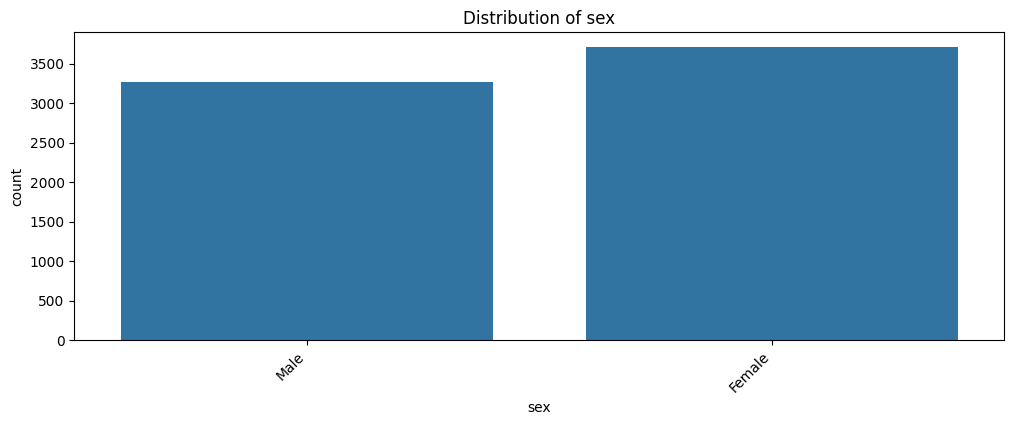

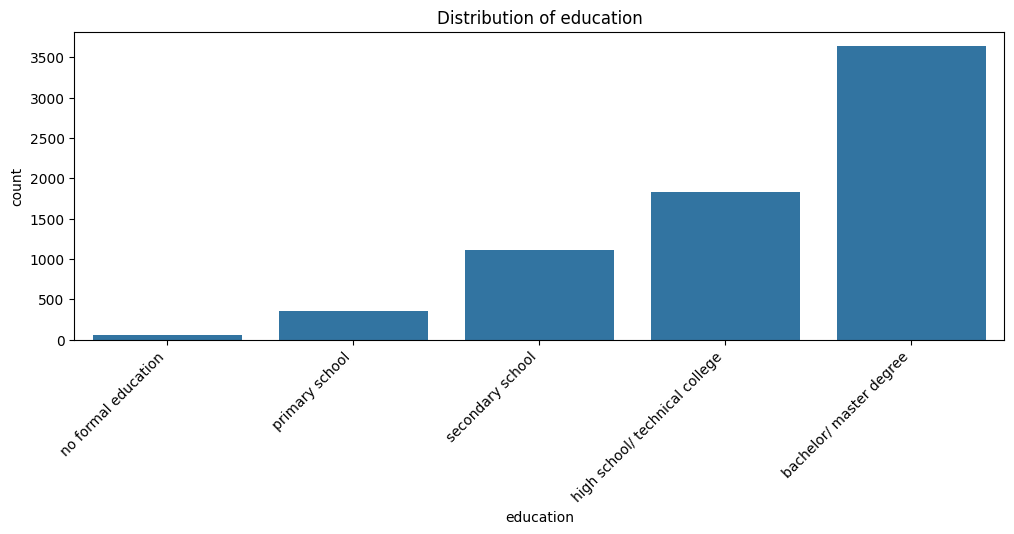

In [ ]:
plot_categorical(marital_df_viz, ['sex', 'education'])

### Bivariate Analysis

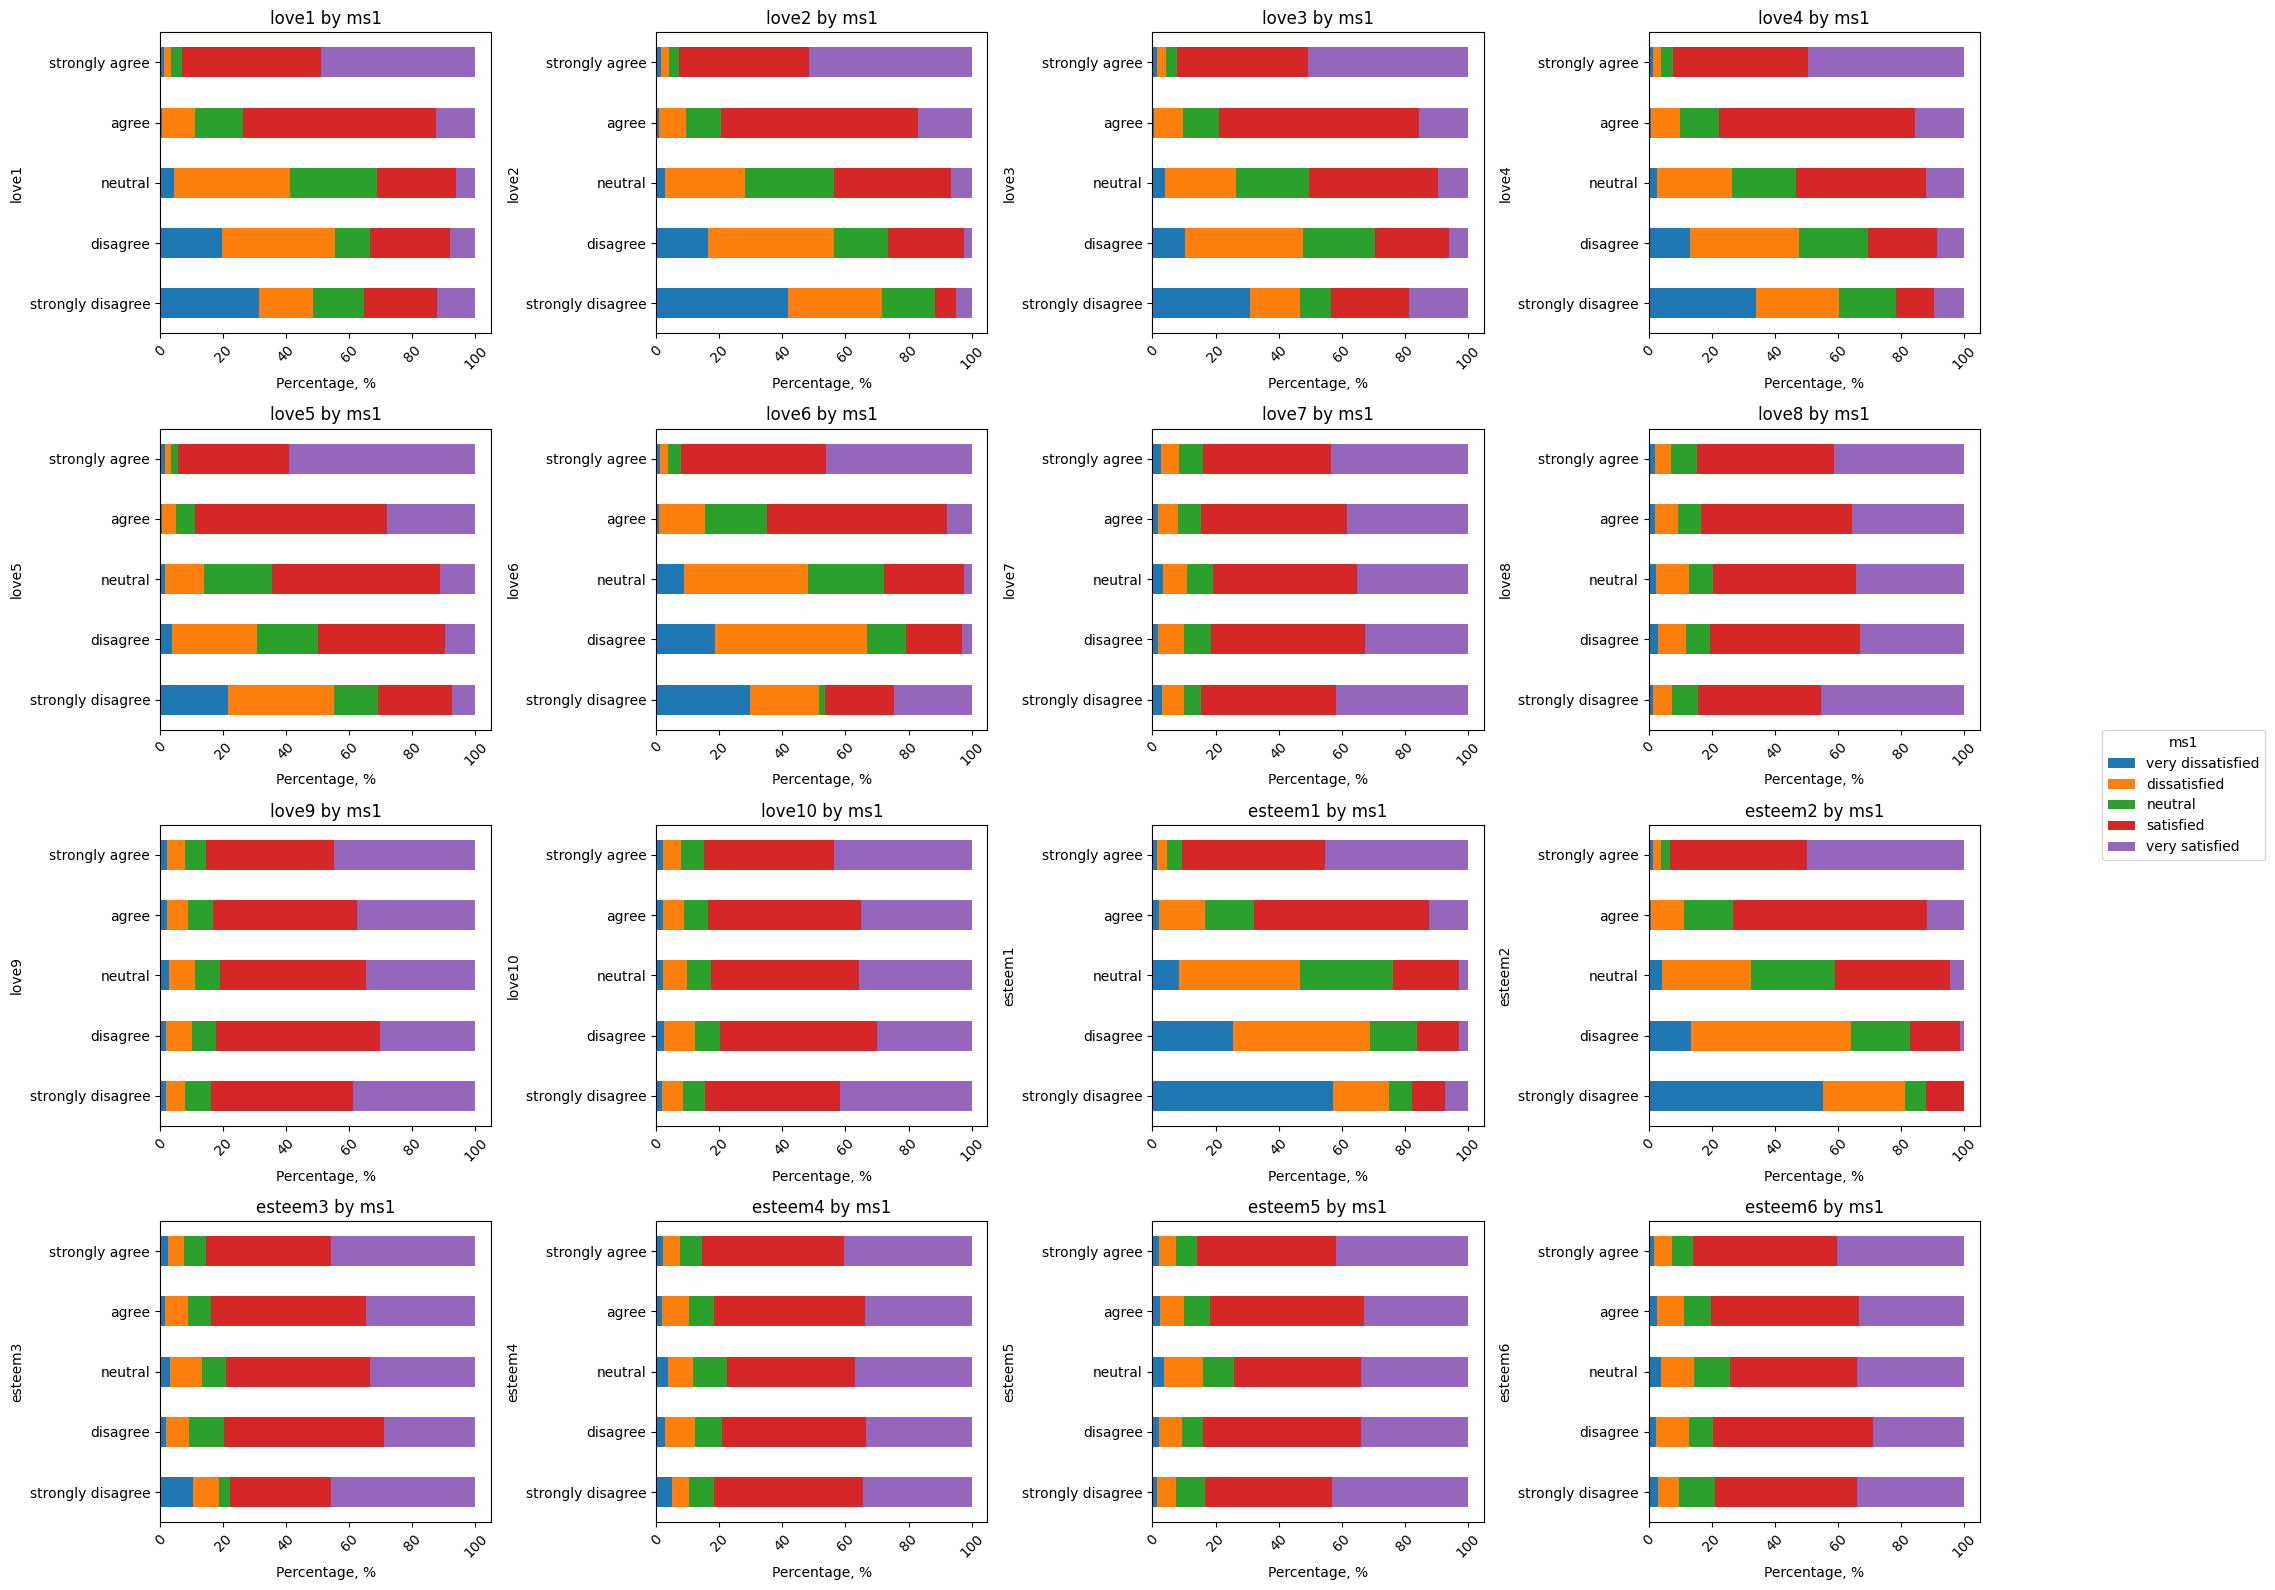

In [ ]:
remaining_ordinal_columns = [
    col for col in ordinal_columns if col not in ["sex", "education"]
]

plot_stacked_barchart(marital_df_viz, "ms1", remaining_ordinal_columns)

### Multivariate Analysis (Spearman Correlation Matrix)

In [ ]:
marital_df_spearman = marital_df_cleaned.copy()

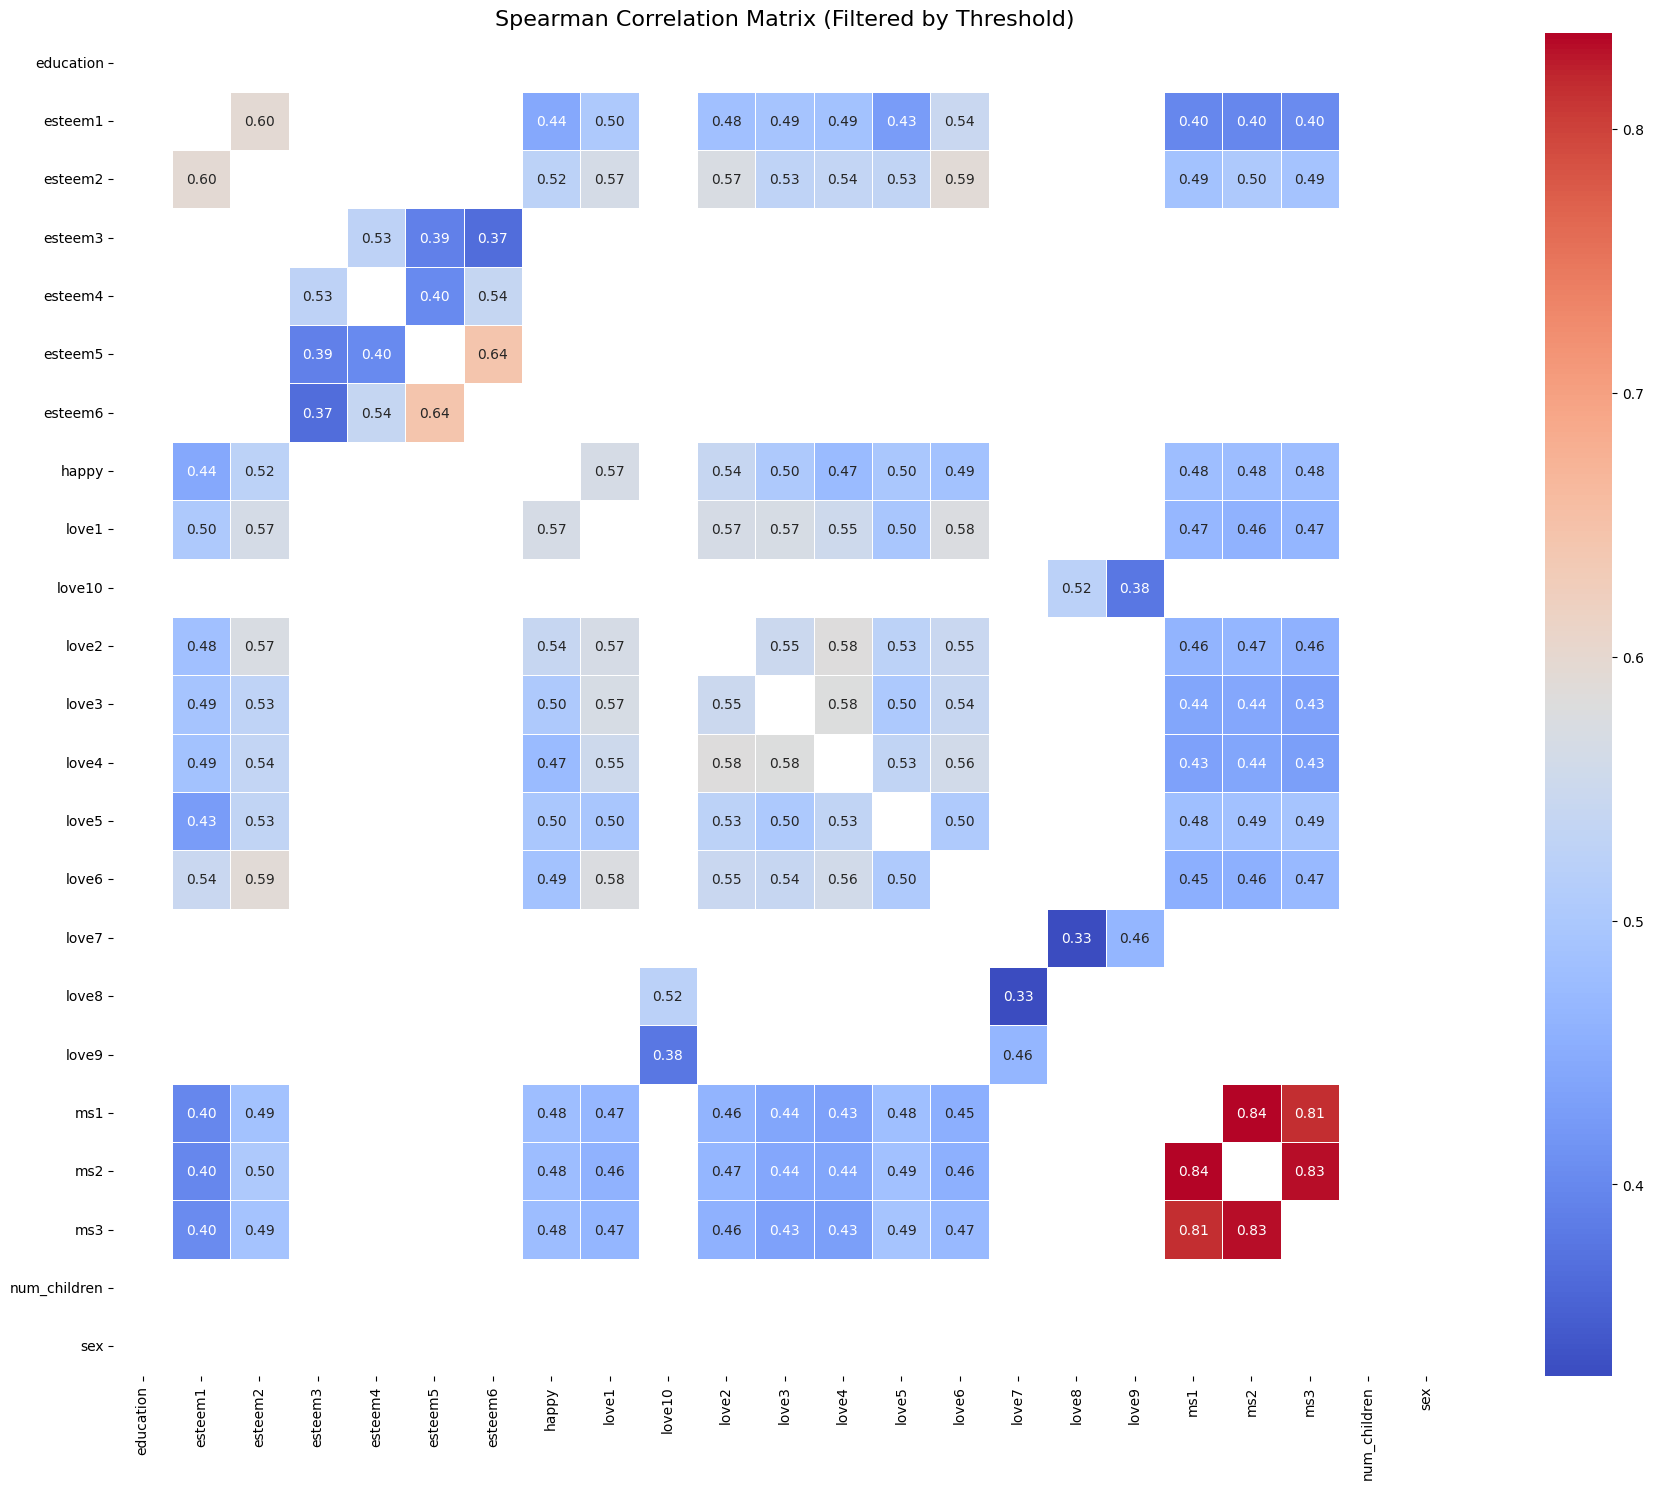

In [ ]:
spearman_corr = marital_df_cleaned.corr(method="spearman")

# Set a threshold for correlation values
threshold = 0.3

# Sort the correlation matrix by column names
spearman_corr_sorted = spearman_corr.sort_index(axis=1).sort_index(axis=0)

# Mask correlations below the threshold
mask = spearman_corr_sorted.abs() < threshold
mask2 = spearman_corr_sorted == 1

# Mask the correlation matrix
spearman_corr_sorted[mask | mask2] = None

# Plot heatmap
plt.figure(figsize=(19, 15))
sns.heatmap(
    spearman_corr_sorted,
    cmap="coolwarm",
    annot=True,
    fmt=".2f",
    cbar=True,
    square=True,
    linewidths=0.5,
    mask=mask,
)

plt.title("Spearman Correlation Matrix (Filtered by Threshold)", fontsize=16)
plt.tight_layout()
plt.show()

In [ ]:
filtered = spearman_corr_sorted[marital_satisfaction_columns].copy()
filtered = filtered.loc[filtered.abs().max(axis=1) > threshold]
filtered = filtered[
    ~filtered.index.isin(marital_satisfaction_columns)
].sort_values(by="ms1", ascending=False)

filtered

,ms1,ms2,ms3
esteem2,0.487815,0.502468,0.490276
love5,0.481535,0.485553,0.491794
happy,0.480432,0.477846,0.477019
love1,0.466655,0.460449,0.465733
love2,0.461020,0.465643,0.458091
love6,0.454324,0.456323,0.471595
love3,0.440255,0.442220,0.433875
love4,0.433596,0.440421,0.429735
esteem1,0.398543,0.398365,0.403842


Based on above sorted correlation, choose ms2 as the dependence variable and drop ms1 and ms2. Then, pick esteem2, love5, happy to plot the spearman correlation again.

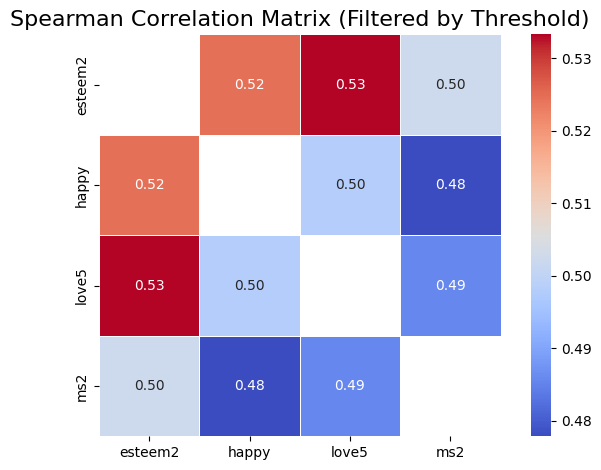

In [ ]:
corr_columns = ["ms2", "esteem2", "love5", "happy"]

spearman_corr2 = marital_df_cleaned[corr_columns].corr(method="spearman")

# Set a threshold for correlation values
threshold = 0.3

# Sort the correlation matrix by column names
spearman_corr_sorted2 = spearman_corr2.sort_index(axis=1).sort_index(axis=0)

# Mask correlations below the threshold
mask = spearman_corr_sorted2.abs() < threshold
mask2 = spearman_corr_sorted2 == 1

# Mask the correlation matrix
spearman_corr_sorted2[mask | mask2] = None

# Plot heatmap
sns.heatmap(
    spearman_corr_sorted2,
    cmap="coolwarm",
    annot=True,
    fmt=".2f",
    cbar=True,
    square=True,
    linewidths=0.5,
    mask=mask,
)

plt.title("Spearman Correlation Matrix (Filtered by Threshold)", fontsize=16)
plt.tight_layout()
plt.show()

## Feature Selection

Choose ms2, love5, esteem2, happy, num_children, marriage_duration, and education

In [ ]:
selected_columns = [
    "ms2",
    "love5",
    "esteem2",
    "happy",
    "education",
    "sex",
    "num_children",
]

## 4. Data Preprocessing Part 2: Preprocessing for ARM

In [ ]:
marital_df_arm = marital_df_cleaned.copy()
marital_df_arm = marital_df_arm[selected_columns]
marital_df_arm.head()

,ms2,love5,esteem2,happy,education,sex,num_children
0,5.0,5.0,5.0,5.0,5.0,1.0,0.0
1,4.0,4.0,5.0,5.0,5.0,1.0,1.0
2,5.0,3.0,5.0,5.0,5.0,1.0,0.0
3,4.0,4.0,4.0,5.0,5.0,1.0,1.0
4,4.0,4.0,5.0,4.0,4.0,1.0,0.0


In [ ]:
for col in selected_columns:
    describe_variable(marital_df_arm, col)

ms2 :
Unique variable description:  How satisfied are you with your wife/husband as a spouse?
Unique values in data:  [1.0, 2.0, 3.0, 4.0, 5.0]
Unique variable scheme:  1-very dissatisfied, 7-very satisfied

love5 :
Unique variable description:  Does your relationship have a romantic side?
Unique values in data:  [1.0, 2.0, 3.0, 4.0, 5.0]
Unique variable scheme:  1-yes, 3-neither yes nor no, 5-no

esteem2 :
Unique variable description:  Are you proud of your husband/wife?
Unique values in data:  [1.0, 2.0, 3.0, 4.0, 5.0]
Unique variable scheme:  1-yes, 3-neither yes nor no, 5-no

happy :
Unique variable description:  Are you happy?
Unique values in data:  [1.0, 2.0, 3.0, 4.0, 5.0]
Unique variable scheme:  1-yes, 3-neither yes nor no, 5-no

education :
Unique variable description:  Education
Unique values in data:  [1.0, 2.0, 3.0, 4.0, 5.0]
Unique variable scheme:  1-no formal education, 2-primary school, 3-secondary school, 4-high school or technical college, 5-bachelor or master degre

### Binary coding

In [ ]:
# usually code 0 as Male, 1 as Female
# x == 2 is Male hence True, so True will be coded as 1
marital_df_arm["sex"] = [x == 2 for x in marital_df_cleaned["sex"]]
marital_df_arm["sex"] = marital_df_arm["sex"].astype(int)
marital_df_arm["sex"].head()

0    0
1    0
2    0
3    0
4    0
Name: sex, dtype: int64

### Binning

num_children binning

In [ ]:
describe_variable(marital_df_arm, 'num_children')

num_children :
Unique variable description:  How many children do you have?
Unique values in data:  [0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 11.0, 12.0]
Unique variable scheme:  Total number of children



In [ ]:
bins = [-1, 0, 1, 2, 12]
labels = ["No children", "1 child", "2 children", "3+ children"]

marital_df_arm["num_children_group"] = pd.cut(
    marital_df_arm["num_children"],
    bins=bins,
    labels=labels,
    include_lowest=True,
)

marital_df_arm["num_children_group"].value_counts().sort_index()

num_children_group
No children    1034
1 child        2008
2 children     2520
3+ children    1425
Name: count, dtype: int64

then drop the numerical values after the binnings are done

In [ ]:
marital_df_arm.drop(columns=['num_children'], inplace=True)

marital_df_arm.head()

,ms2,love5,esteem2,happy,education,sex,num_children_group
0,5.0,5.0,5.0,5.0,5.0,0,No children
1,4.0,4.0,5.0,5.0,5.0,0,1 child
2,5.0,3.0,5.0,5.0,5.0,0,No children
3,4.0,4.0,4.0,5.0,5.0,0,1 child
4,4.0,4.0,5.0,4.0,4.0,0,No children


### Convert bins to order

In [ ]:
ordinal_mappings = {
    "num_children_group": {
        "No children": 0,
        "1 child": 1,
        "2 children": 2,
        "3+ children": 3,
    }
}

In [ ]:
for col, mapping in ordinal_mappings.items():
    marital_df_arm[col] = marital_df_arm[col].map(mapping)

In [ ]:
marital_df_arm.head()

,ms2,love5,esteem2,happy,education,sex,num_children_group
0,5.0,5.0,5.0,5.0,5.0,0,0
1,4.0,4.0,5.0,5.0,5.0,0,1
2,5.0,3.0,5.0,5.0,5.0,0,0
3,4.0,4.0,4.0,5.0,5.0,0,1
4,4.0,4.0,5.0,4.0,4.0,0,0


In [ ]:
for col in marital_df_arm.columns:
    print(col, ":")
    print(sorted(marital_df_arm[col].unique()))
    print()

ms2 :
[np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0)]

love5 :
[np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0)]

esteem2 :
[np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0)]

happy :
[np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0)]

education :
[np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0)]

sex :
[np.int64(0), np.int64(1)]

num_children_group :
[0, 1, 2, 3]



### Binarize data

In [ ]:
for col in ["ms2", "love5", "esteem2", "happy", "education"]:
    marital_df_arm[f"{col}_high"] = (marital_df_arm[col] >= 4).astype(int)
    marital_df_arm[f"{col}_low"] = (marital_df_arm[col] <= 3).astype(int)

In [ ]:
marital_df_arm = pd.get_dummies(
    marital_df_arm, columns=["num_children_group", "sex"], prefix_sep="="
)

In [ ]:
marital_df_arm.head()

,ms2,love5,esteem2,happy,education,ms2_high,ms2_low,love5_high,love5_low,esteem2_high,...,happy_high,happy_low,education_high,education_low,num_children_group=0,num_children_group=1,num_children_group=2,num_children_group=3,sex=0,sex=1
0,5.0,5.0,5.0,5.0,5.0,1,0,1,0,1,...,1,0,1,0,True,False,False,False,True,False
1,4.0,4.0,5.0,5.0,5.0,1,0,1,0,1,...,1,0,1,0,False,True,False,False,True,False
2,5.0,3.0,5.0,5.0,5.0,1,0,0,1,1,...,1,0,1,0,True,False,False,False,True,False
3,4.0,4.0,4.0,5.0,5.0,1,0,1,0,1,...,1,0,1,0,False,True,False,False,True,False
4,4.0,4.0,5.0,4.0,4.0,1,0,1,0,1,...,1,0,1,0,True,False,False,False,True,False


In [ ]:
marital_df_arm = marital_df_arm.drop(
    columns=["ms2", "love5", "esteem2", "happy", "education"]
)
marital_df_arm.head()

,ms2_high,ms2_low,love5_high,love5_low,esteem2_high,esteem2_low,happy_high,happy_low,education_high,education_low,num_children_group=0,num_children_group=1,num_children_group=2,num_children_group=3,sex=0,sex=1
0,1,0,1,0,1,0,1,0,1,0,True,False,False,False,True,False
1,1,0,1,0,1,0,1,0,1,0,False,True,False,False,True,False
2,1,0,0,1,1,0,1,0,1,0,True,False,False,False,True,False
3,1,0,1,0,1,0,1,0,1,0,False,True,False,False,True,False
4,1,0,1,0,1,0,1,0,1,0,True,False,False,False,True,False


In [ ]:
marital_df_arm.columns

Index(['ms2_high', 'ms2_low', 'love5_high', 'love5_low', 'esteem2_high',
       'esteem2_low', 'happy_high', 'happy_low', 'education_high',
       'education_low', 'num_children_group=0', 'num_children_group=1',
       'num_children_group=2', 'num_children_group=3', 'sex=0', 'sex=1'],
      dtype='object')

## 5. Data Mining (ARM)

In [ ]:
min_support = 0.05
min_lift = 1.1

# Find frequent itemsets
frequent_itemsets = apriori(
    marital_df_arm, min_support=min_support, use_colnames=True
)

# Generate association rules
rules = association_rules(
    frequent_itemsets, metric="lift", min_threshold=min_lift
)

ms2_high_rules = rules[rules["consequents"] == {"ms2_high"}]
ms2_low_rules = rules[rules["consequents"] == {"ms2_low"}]

/run/media/weida/SSD1/MMU Stuff/CDS6314 - DATA MINING/Assignment/assignment/lib/python3.11/site-packages/mlxtend/frequent_patterns/fpcommon.py:161: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


In [ ]:
ms2_high_rules.sort_values(by='lift', ascending=False).head()

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
3782,"(sex=1, esteem2_high, num_children_group=0, ed...",(ms2_high),0.054673,0.837269,0.053242,0.973822,1.163093,1.0,0.007466,6.216316,0.148333,0.063481,0.839133,0.518706
2609,"(sex=1, esteem2_high, num_children_group=0, ha...",(ms2_high),0.060827,0.837269,0.058967,0.969412,1.157826,1.0,0.008038,5.320045,0.145141,0.070271,0.812032,0.519920
2963,"(sex=1, esteem2_high, num_children_group=0, ed...",(ms2_high),0.056247,0.837269,0.054387,0.966921,1.154851,1.0,0.007293,4.919477,0.142079,0.064813,0.796726,0.515939
3210,"(sex=1, num_children_group=0, education_high, ...",(ms2_high),0.055675,0.837269,0.053814,0.966581,1.154445,1.0,0.007199,4.869406,0.141670,0.064131,0.794636,0.515427
2194,"(esteem2_high, num_children_group=0, education...",(ms2_high),0.106770,0.837269,0.102619,0.961126,1.147929,1.0,0.013224,4.186109,0.144270,0.121960,0.761115,0.541845


In [ ]:
ms2_low_rules.sort_values(by='lift', ascending=False).head()

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
76,"(esteem2_low, love5_low)",(ms2_low),0.074853,0.162731,0.054530,0.728489,4.476654,1.0,0.042349,3.083745,0.839455,0.297889,0.675719,0.531791
5,(esteem2_low),(ms2_low),0.091742,0.162731,0.062688,0.683307,4.199005,1.0,0.047759,2.643791,0.838801,0.326866,0.621755,0.534266
82,"(happy_low, love5_low)",(ms2_low),0.080864,0.162731,0.054959,0.679646,4.176505,1.0,0.041800,2.613575,0.827479,0.291351,0.617382,0.508688
7,(happy_low),(ms2_low),0.116645,0.162731,0.067411,0.577914,3.551351,1.0,0.048429,1.983647,0.813283,0.318028,0.495878,0.496081
92,"(sex=1, love5_low)",(ms2_low),0.132246,0.162731,0.065837,0.497835,3.059258,1.0,0.044316,1.667321,0.775707,0.287320,0.400235,0.451204


## 6. Knowledge Evaluation

In [ ]:
# To display full result instead of '...'
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 0)

# To ensure consistent result every time running the code
random.seed(0)
np.random.seed(0)

### Q1. Does the combination of high self-esteem, happiness, and love predict higher marital satisfaction in men?

In [ ]:
q1_rules = ms2_high_rules[
    ms2_high_rules["antecedents"].apply(
        lambda x: x
        == frozenset({"sex=1", "esteem2_high", "happy_high", "love5_high"})
    )
]
q1_rules = q1_rules.sort_values(by="lift", ascending=False)
q1_rules

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
876,"(love5_high, sex=1, happy_high, esteem2_high)",(ms2_high),0.374696,0.837269,0.35151,0.938121,1.120453,1.0,0.037789,2.62981,0.171922,0.408516,0.619744,0.678975


Confidence: High (0.938121), indicating strong predictive relationship.

Lift: Moderate (1.120453), suggesting positive association but not a strong one.

Support: 0.35151, a solid proportion for the combination.

Conclusion: The combination of high self-esteem, happiness, and love is linked with higher marital satisfaction in men, but the strength is moderate (lift > 1).

### Q2. Is having no children a significant moderator for emotional factors in high marital satisfaction in women?

In [ ]:
q2_rules = ms2_high_rules[
    ms2_high_rules["antecedents"].apply(
        lambda x: "num_children_group=0" in x
        and "sex=0" in x
        and {"esteem2_high", "happy_high", "love5_high"}.issubset(x)
    )
]
q2_rules = q2_rules.sort_values(by="lift", ascending=False)
q2_rules

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
2556,"(sex=0, esteem2_high, num_children_group=0, happy_high, love5_high)",(ms2_high),0.058108,0.837269,0.054816,0.94335,1.126698,1.0,0.006164,2.872552,0.119388,0.065214,0.651878,0.50441


Confidence: High (0.94335), showing strong predictive relationship.

Lift: Moderate (1.126698), suggesting the combination has a positive influence but is not very strong.

Support: 0.054816, indicating a reasonable frequency for the combination.

Conclusion: Having no children is a significant moderator for emotional factors in high marital satisfaction in females, with high confidence but moderate lift.

### Q3. Does low self-esteem strongly predict low marital satisfaction.

In [ ]:
q3_rules = ms2_low_rules[
    ms2_low_rules["antecedents"].apply(lambda x: {"esteem2_low"}.issubset(x))
]
q3_rules = q3_rules.sort_values(by="lift", ascending=False)
q3_rules

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
76,"(esteem2_low, love5_low)",(ms2_low),0.074853,0.162731,0.054530,0.728489,4.476654,1.0,0.042349,3.083745,0.839455,0.297889,0.675719,0.531791
5,(esteem2_low),(ms2_low),0.091742,0.162731,0.062688,0.683307,4.199005,1.0,0.047759,2.643791,0.838801,0.326866,0.621755,0.534266


Confidence: High (0.728489 for one rule, 0.683307 for another), suggesting that low self-esteem strongly correlates with low marital satisfaction.

Lift: Very high (4.476654 for one rule), indicating a strong association between low self-esteem and low marital satisfaction.

Support: Moderate (0.054530, 0.062688), meaning these patterns are reasonably frequent.

Conclusion: Low self-esteem strongly predicts low marital satisfaction, especially when combined with low love, as reflected by high lift values and significant confidence.

### Q4. Do individuals with high self-esteem but low love still experience low marital satisfaction?

In [ ]:
q4_rules = ms2_low_rules[
    ms2_low_rules["antecedents"].apply(
        lambda x: {"esteem2_high", "love5_low"}.issubset(x)
    )
]
q4_rules = q4_rules.sort_values(by="lift", ascending=False)
q4_rules

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
71,"(esteem2_high, love5_low)",(ms2_low),0.15901,0.162731,0.050379,0.316832,1.946968,1.0,0.024504,1.225568,0.578343,0.185654,0.184052,0.313209


Confidence: Moderate (0.316832), indicating some likelihood that individuals with high self-esteem but low love experience low marital satisfaction.

Lift: High (1.946968), suggesting that this combination significantly increases the probability of low marital satisfaction.

Support: Low (0.050379), meaning that this pattern is less frequent in the dataset.

Conclusion: Individuals with high self-esteem but low love tend to experience low marital satisfaction, as reflected by high lift, though it is a less common pattern (low support).

## 7. References

1. https://www.datacamp.com/tutorial/apriori-algorithm
2. https://chatgpt.com/
3. https://grok.com/